In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

for name in uploaded.keys():
    if name.endswith(".zip"):
        with zipfile.ZipFile(name, 'r') as z:
            z.extractall("task1ds")
            print("Extracted to ./task1ds")


Saving task1ds.zip to task1ds.zip
Extracted to ./task1ds


In [ ]:
data_dir = Path("./task1ds")
csv_main = data_dir / "API_SP.POP.TOTL_DS2_en_csv_v2_582557.csv"
csv_meta = data_dir / "Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_582557.csv"
pop = pd.read_csv(csv_main, skiprows=4)
meta = pd.read_csv(csv_meta)
merged = pop.merge(meta[["Country Code", "Region"]], on="Country Code", how="left")
countries = merged[merged["Region"].notna()].copy()
year_cols = [c for c in countries.columns if c.isdigit()]
latest_year = max(year_cols, key=int)
print("Most recent year in file:", latest_year)
df_year = countries[["Country Name", "Country Code", latest_year]].rename(columns={latest_year: "Population"})
df_year = df_year.dropna(subset=["Population"]).copy()
df_year["Population"] = df_year["Population"].astype(int)
df_year.sort_values("Population", ascending=False).head(10)


Most recent year in file: 2024


,Country Name,Country Code,Population
109,India,IND,1450935791
40,China,CHN,1408975000
251,United States,USA,340110988
106,Indonesia,IDN,283487931
184,Pakistan,PAK,251269164
174,Nigeria,NGA,232679478
29,Brazil,BRA,211998573
20,Bangladesh,BGD,173562364
202,Russian Federation,RUS,143533851
72,Ethiopia,ETH,132059767


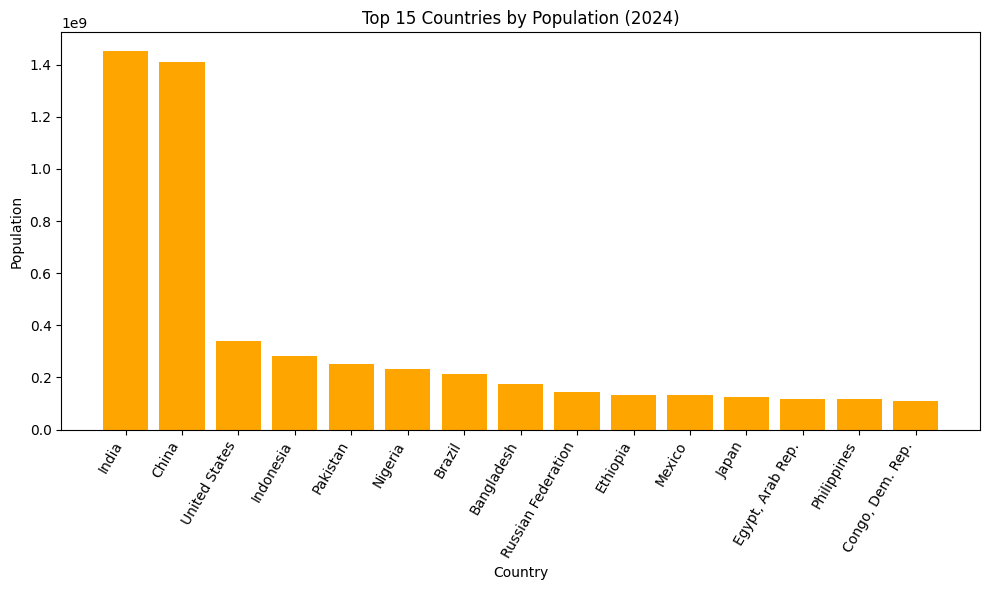

In [ ]:
top_n = 15
top_countries = df_year.sort_values("Population", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_countries["Country Name"], top_countries["Population"], color="orange")
plt.title(f"Top {top_n} Countries by Population ({latest_year})")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("top_countries_bar.png", dpi=150)
plt.show()


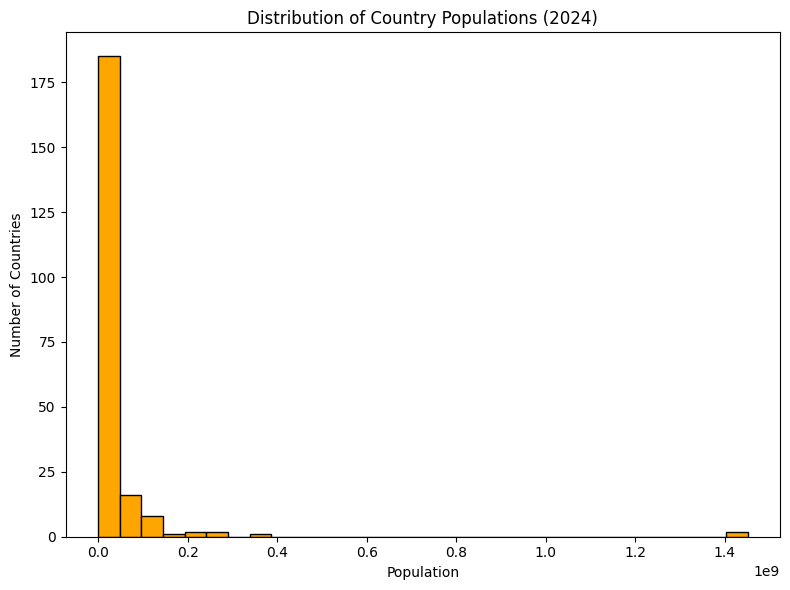

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df_year["Population"], bins=30, color="orange", edgecolor="black")
plt.title(f"Distribution of Country Populations ({latest_year})")
plt.xlabel("Population")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.savefig("population_histogram.png", dpi=150)
plt.show()


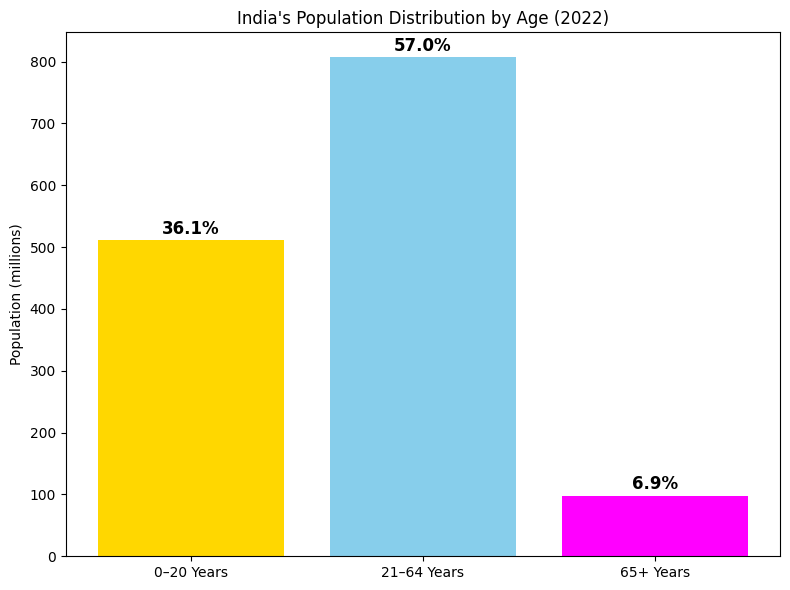

In [ ]:
import matplotlib.pyplot as plt
age_groups = ["0–20 Years", "21–64 Years", "65+ Years"]
population_mn = [512, 807, 98]
percentages = [36.1, 57.0, 6.9]
plt.figure(figsize=(8,6))
bars = plt.bar(age_groups, population_mn, color=["gold", "skyblue", "magenta"])
for bar, pct in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{pct}%", ha='center', fontsize=12, fontweight="bold")

plt.title("India's Population Distribution by Age (2022)")
plt.ylabel("Population (millions)")
plt.tight_layout()
plt.show()
